In [53]:
from src import *
from myutils import *

In [ ]:
def loadnpz(file):
    file = os.path.expanduser(file)
    npz = np.load(file, allow_pickle=True)
    meta = npz['metadata'].item()
    meta_ = MetaData(meta.measurement, meta.ground_truth, 'frequency', meta.amplitude, meta.pwm_duty, timestamp=meta.timestamp)

    dic = {}
    for k in npz.files:
        if k.lower() == 'noise':
            dic['background'] = npz[k]
        
        elif k.lower() == 'frequency_estimates':
            dic['estimates_a'] = npz[k]

        elif k.lower() == 'metadata':
            dic[k] = meta_

        elif k.lower() == 'velocity_estimates':
            pass

        elif k.lower() == 'start_point_estimates':
            pass

        else:
            dic[k] = npz[k]

    return Estimates(**dic)

In [ ]:
from glob import glob

In [ ]:
tree = [
    'noisy/di_5px',
    'noisy/spade_5px',

    '0noise/di_5px',
    '0noise/spade_5px',

    '0noise/di_3px',
    '0noise/spade_3px',
]

In [ ]:
def main(_folder):
    src = os.path.join('__estimates__.old', _folder)
    dst = os.path.join('__estimates__', _folder)
    for file in tqdm(glob(src+'/*')):
        c = loadnpz(file)
        c.savez(dst)


In [58]:
c = LoadEstimates(r'__estimates__\noisy\di_5px\di_5px_f0.2_d0.npz')

In [59]:
c.time_domain

array([[ 0.94377921,  1.03270098,  0.75560114, ...,  0.9587548 ,
        -1.30706562, -0.97960109],
       [ 0.66000378,  0.87913015,  0.87192466, ...,  1.0610656 ,
        -1.07637605, -1.04435051],
       [ 0.77475268,  1.03790098,  0.8969439 , ...,  0.85601091,
        -0.91312687, -0.84994941],
       ...,
       [ 0.81311484,  0.4690305 ,  0.66119239, ...,  0.59400011,
        -1.36911188, -1.12151169],
       [ 0.76673646,  0.72545699,  0.83373692, ...,  0.62634687,
        -1.17897966, -1.16281428],
       [ 1.00772951,  0.90137202,  0.50750462, ...,  0.89809803,
        -1.03756855, -1.11795425]])

In [50]:
td1 = td_estimator('spade', c.cropped_data, c.background, method='mle', standardize=False)
td2 = td_estimator('spade', c.cropped_data, c.background, method='lse', standardize=False)
td3 = td_estimator('spade', c.cropped_data, c.background, method='zhou2023', standardize=False)

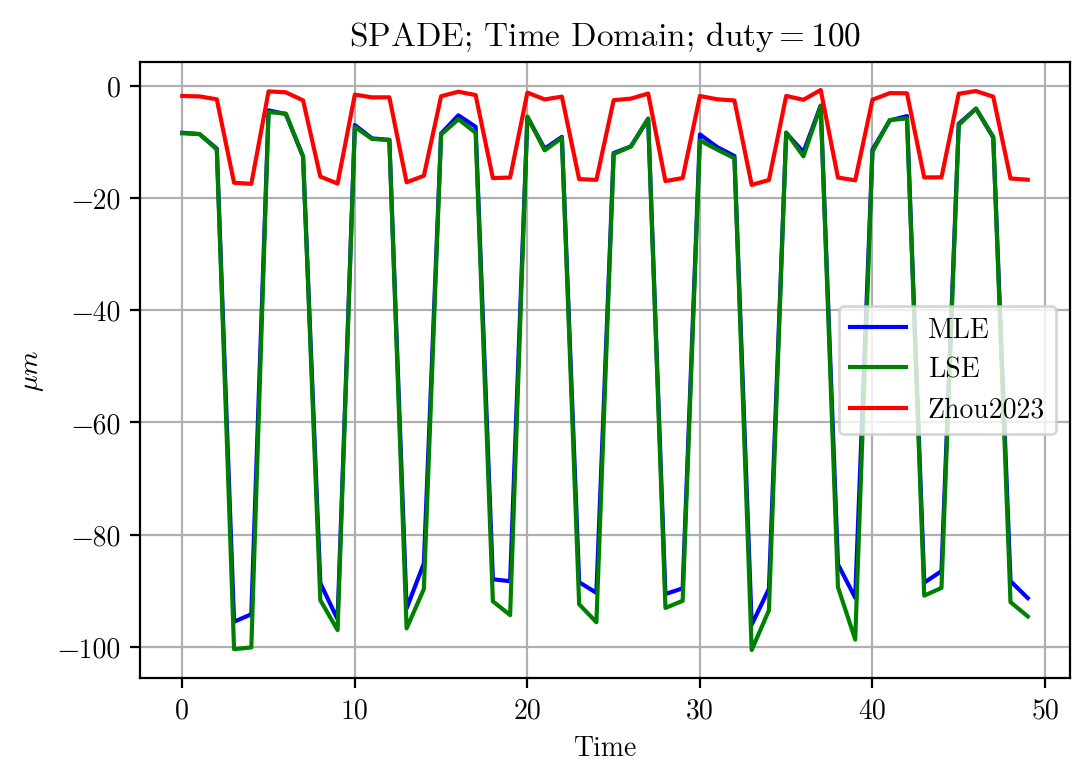

In [52]:
plot(td1.mean(0), label='MLE')
plot(td2.mean(0), label='LSE', xlabel='Time', ylabel=r'$\mu m$')
plot(td3.mean(0), title=r'SPADE; Time Domain; ${\rm duty} = 100$', label='Zhou2023')

In [44]:
c = LoadEstimates(r'__estimates__\noisy\di_5px\di_5px_f0.2_d90.npz')

In [45]:
td1 = td_estimator('di', c.cropped_data, c.background, method='mle', standardize=False)
td2 = td_estimator('di', c.cropped_data, c.background, method='lse', standardize=False)
td3 = td_estimator('di', c.cropped_data, c.background, method='simple', standardize=False)

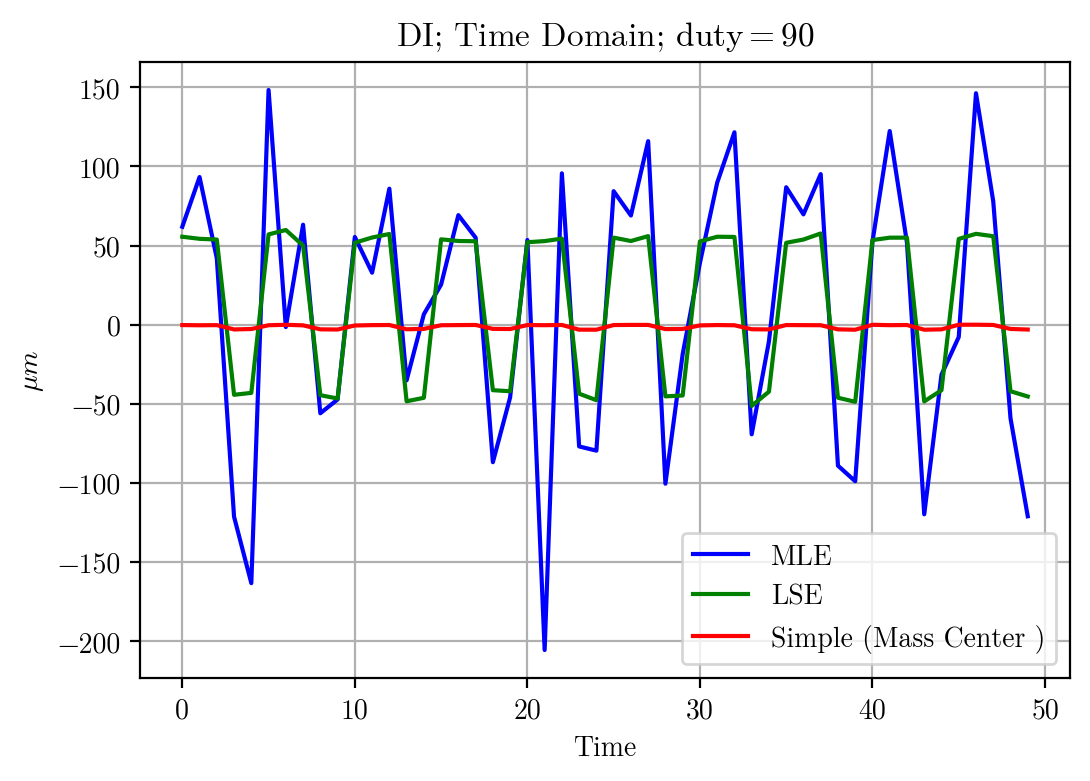

In [46]:
plot(td1.mean(0), label='MLE')
plot(td2.mean(0), label='LSE', xlabel='Time', ylabel=r'$\mu m$')
plot(td3.mean(0), title=r'DI; Time Domain; ${\rm duty} = 90$', label='Simple (Mass Center )')

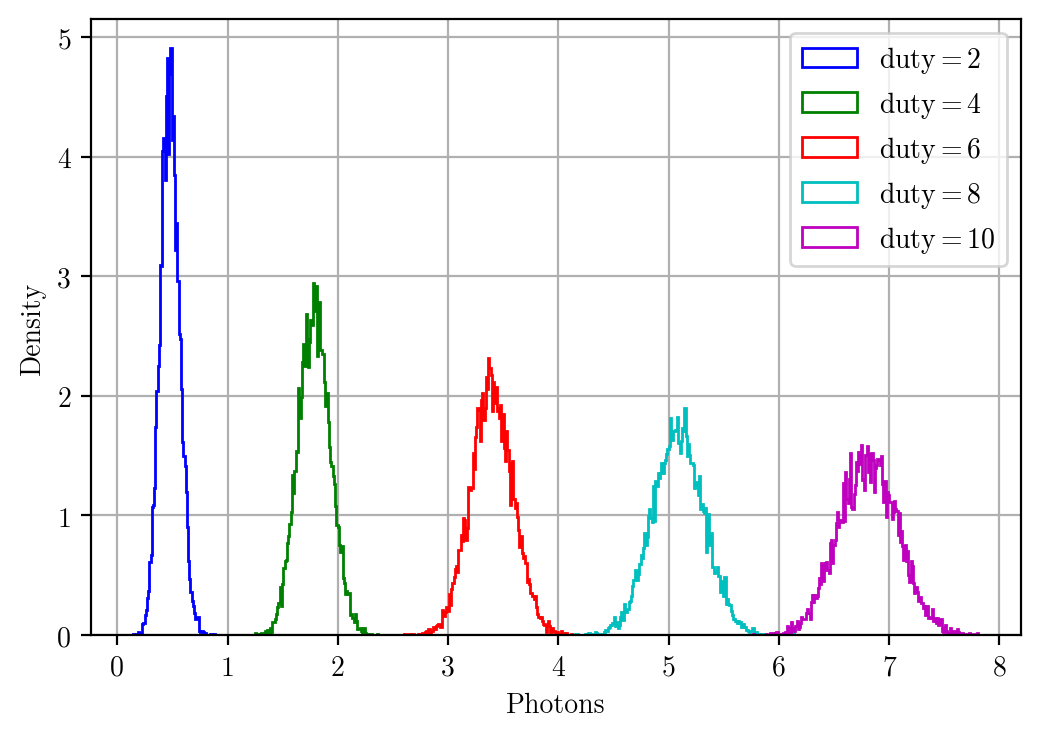

In [37]:
for d in (2, 4, 6, 8, 10):
    c = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz')
    hist(qCMOS.convert2photons(np.ravel(c.background)), bins=10*round(c.background.max() - c.background.min()), label=r'${\rm duty}' + f' = {d}$')
    plt.xlabel('Photons')
    plt.ylabel('Density')